<a href="https://colab.research.google.com/github/Emelsmsk/yapay-sinir-ag-/blob/main/yapay_sinirag%C4%B1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
size = 200
std = 0.1
data = torch.randint(low=0, high=2, size=(size, 2), dtype=torch.float32)
label = (data.sum(dim=1) == 1).to(torch.long)
data_shape = data.shape
data += std * torch.randn(data_shape)

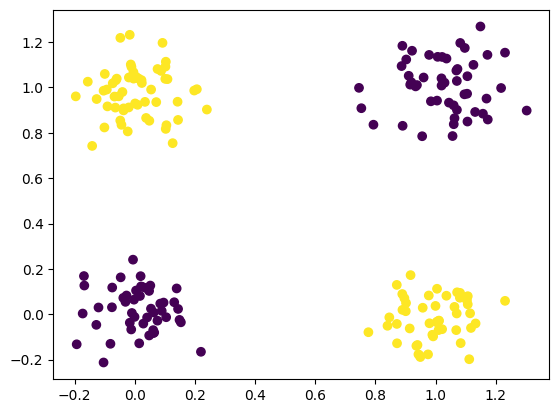

In [ ]:
plt.scatter(data[:,0].numpy(), data[:,1].numpy(), c = label.numpy())
plt.show()

In [ ]:
x = data
y = label
print(x[:1])
print(y[:1])
y = y.to(dtype=torch.float32).reshape(-1, 1)

tensor([[-0.1675,  0.1266]])
tensor([0])


In [ ]:
model = nn.Sequential(
    nn.Linear(2, 10),
    nn.ReLU(),
    nn.Linear(10, 1),
    nn.Sigmoid())
print(model)

Sequential(
  (0): Linear(in_features=2, out_features=10, bias=True)
  (1): ReLU()
  (2): Linear(in_features=10, out_features=1, bias=True)
  (3): Sigmoid()
)


In [ ]:
params = []
for param in model.parameters():
    params.append(param.view(-1))
params = torch.cat(params)
print(params)

tensor([-0.0254, -0.5516,  0.4776,  0.6235,  0.0564,  0.4304,  0.5292, -0.2927,
         0.2637,  0.1049, -0.6092,  0.0993, -0.6174,  0.3951,  0.0433, -0.2637,
         0.5218, -0.4243, -0.1514, -0.1098, -0.2611,  0.0250,  0.1306, -0.0834,
         0.0489,  0.7062,  0.6528, -0.4310, -0.5894, -0.6941,  0.0742, -0.0639,
        -0.0233,  0.2893,  0.1045,  0.0741,  0.0534,  0.2471,  0.2898,  0.2324,
         0.2025], grad_fn=<CatBackward0>)


In [ ]:
print(model(x[:1]))

tensor([[0.5751]], grad_fn=<SigmoidBackward0>)


In [ ]:
loss_fn = nn.BCELoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)

In [ ]:
n_epoch = 100
batch_size = 10
for epoch in range(n_epoch):
  for i in range(0, len(x), batch_size):
    xbatch = x[i:i+batch_size]
    y_pred = model(xbatch)
    ybatch = y[i:i+batch_size]
    loss = loss_fn(y_pred, ybatch)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    print(f'Finished epoch {epoch}, latest loss {loss}')

Finished epoch 0, latest loss 0.0007106928969733417
Finished epoch 0, latest loss 0.002882435219362378
Finished epoch 0, latest loss 0.0001428171235602349
Finished epoch 0, latest loss 0.000410077947890386
Finished epoch 0, latest loss 0.0005296677118167281
Finished epoch 0, latest loss 0.0016921249916777015
Finished epoch 0, latest loss 0.00019150361185893416
Finished epoch 0, latest loss 0.00035752885742112994
Finished epoch 0, latest loss 0.0003780552069656551
Finished epoch 0, latest loss 0.00015503852046094835
Finished epoch 0, latest loss 0.00012828086619265378
Finished epoch 0, latest loss 0.0001251569192390889
Finished epoch 0, latest loss 0.00014079654647503048
Finished epoch 0, latest loss 0.0006288201548159122
Finished epoch 0, latest loss 0.0018520057201385498
Finished epoch 0, latest loss 0.00047808076487854123
Finished epoch 0, latest loss 0.0006288706208579242
Finished epoch 0, latest loss 0.0014111105119809508
Finished epoch 0, latest loss 0.0014240536838769913
Finished

In [ ]:
y_pred = model(x)
accuracy = (y_pred.round() == y).float().mean()
print(f"Accuracy {accuracy}")

Accuracy 1.0


In [ ]:
predictions = (model(x) > 0.5).int()
for i in range(5):
  print('%s => %d (expecdet %d)' % (x[i].tolist(), predictions[i], y[i]))

[-0.1675492376089096, 0.12657073140144348] => 0 (expecdet 0)
[-0.0042954678647220135, 1.067064642906189] => 1 (expecdet 1)
[1.1058893203735352, 0.8493924736976624] => 0 (expecdet 0)
[0.19772090017795563, 0.9860110878944397] => 1 (expecdet 1)
[-0.0024825334548950195, 0.06430887430906296] => 0 (expecdet 0)
